In [3]:
import os,re
from PIL import Image
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
read_csv = pd.read_csv('class_dict_seg.csv',index_col=False,skipinitialspace=True)
read_csv

,name,r,g,b
0,unlabeled,0,0,0
1,paved-area,128,64,128
2,dirt,130,76,0
3,grass,0,102,0
4,gravel,112,103,87
5,water,28,42,168
6,rocks,48,41,30
7,pool,0,50,89
8,vegetation,107,142,35
9,roof,70,70,70


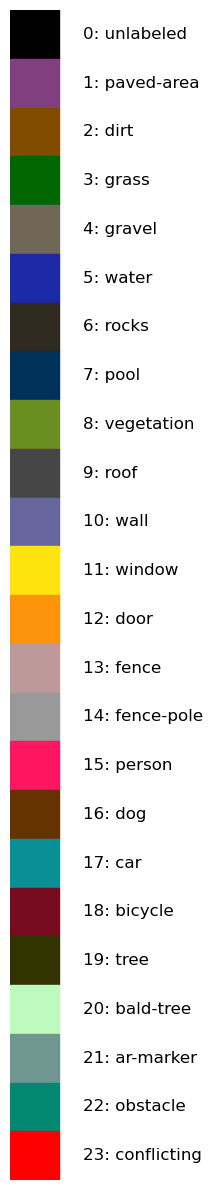

In [6]:
def plot_color_mapping(data):
    # Extract RGB values and class names from the DataFrame
    COLOR_MAPPING = {
        (row['r'], row['g'], row['b']): index for index, row in data.iterrows()
    }
    LABEL_NAMES = {
        index: row['name'] for index, row in data.iterrows()
    }
    
    # Create a figure and axis
    fig, ax = plt.subplots(1, 1, figsize=(6, len(COLOR_MAPPING) * 0.5))

    # Iterate through each color and label
    for i, ((r, g, b), class_id) in enumerate(COLOR_MAPPING.items()):
        # Normalize RGB values to the 0-1 range for matplotlib
        color = [r / 255, g / 255, b / 255]
        
        # Create a rectangle patch for the color
        rect = plt.Rectangle((0, i), 1, 1, color=color)
        ax.add_patch(rect)
        
        # Display the class label text
        text = f"{class_id}: {LABEL_NAMES[class_id]}"
        ax.text(1.5, i + 0.5, text, verticalalignment='center', fontsize=12)
    
    # Remove axes
    ax.axis('off')

    # Set the aspect ratio to ensure the rectangles remain square
    ax.set_aspect('equal')

    # Adjust the plot limits based on the number of colors
    ax.set_xlim([0, 3])
    ax.set_ylim([0, len(COLOR_MAPPING)])

    # Invert the y-axis so the first class appears at the top
    ax.invert_yaxis()

    # Display the plot
    plt.tight_layout()
    plt.show()
plot_color_mapping(read_csv)

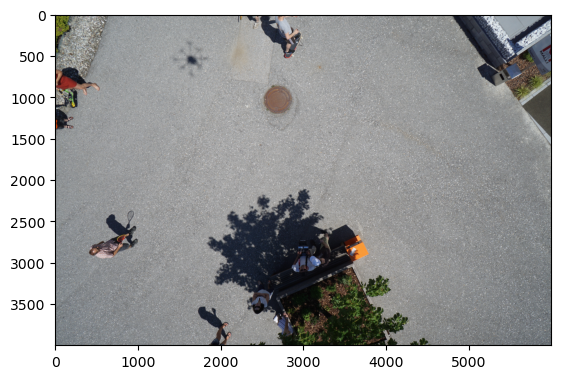

In [7]:
# original image
image = Image.open('dataset/semantic_drone_dataset/original_images/000.jpg')
image = np.array(image)
plt.imshow(image)

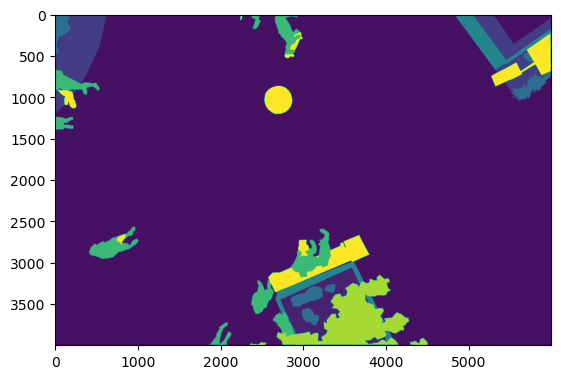

In [9]:
# label image
label = Image.open('dataset/semantic_drone_dataset/label_images_semantic/000.png')
label = np.array(label)
plt.imshow(label)

In [10]:
image.shape, label.shape

((4000, 6000, 3), (4000, 6000))

In [11]:
image.min(), image.max()

(0, 255)

In [12]:
label.min(), label.max()

(0, 22)

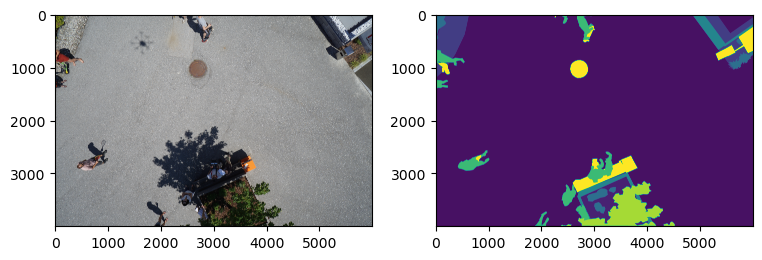

In [13]:
plt.figure(figsize = (9, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(label)

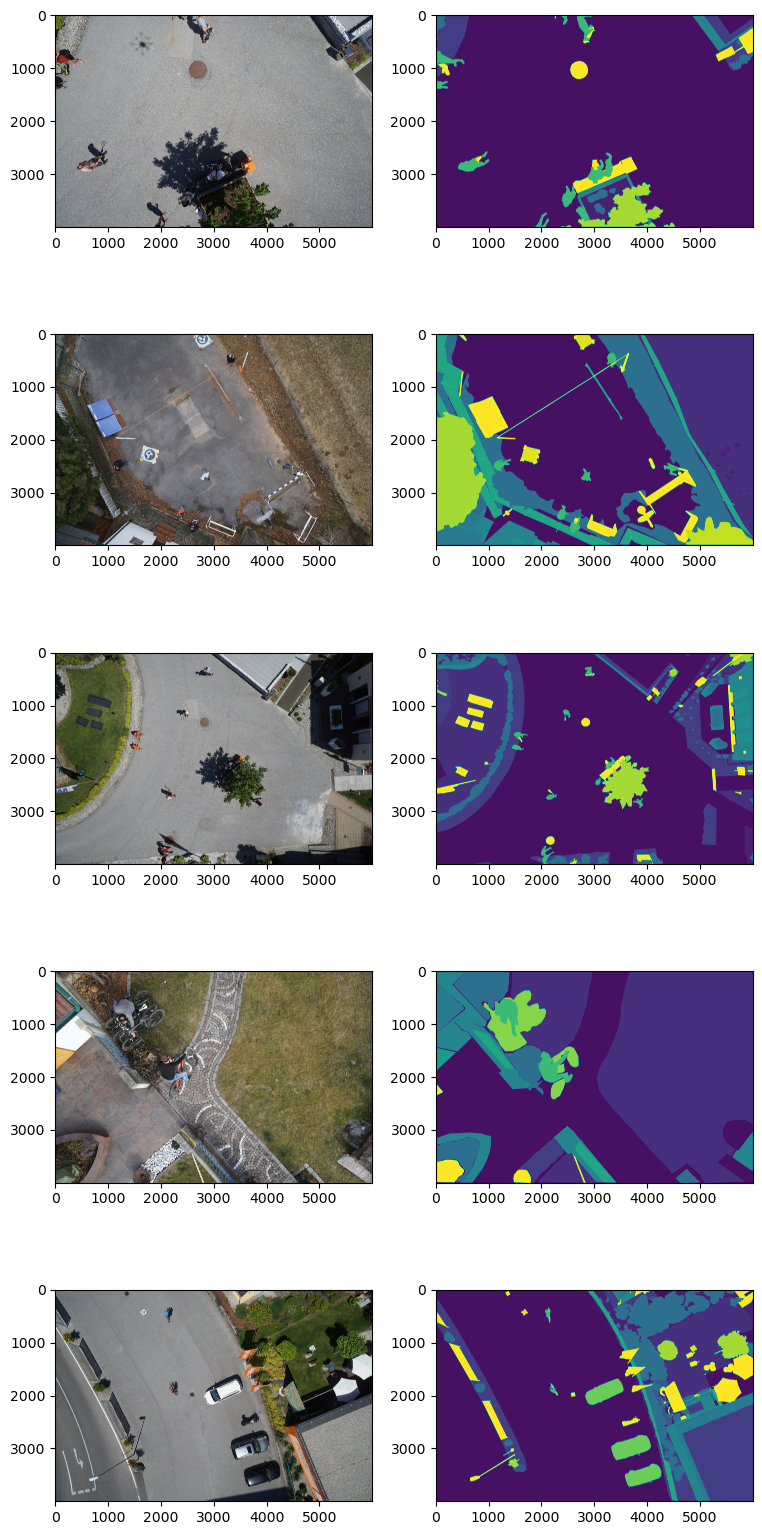

In [16]:
# 5 pairs of original and label images
n_max_imgs = 5

plt.figure(figsize = (9, 20))
for n in range(n_max_imgs):

    image = Image.open(f'dataset/semantic_drone_dataset/original_images/00{n}.jpg')
    image = np.array(image)

    label = Image.open(f'dataset/semantic_drone_dataset/label_images_semantic/00{n}.png')
    label = np.array(label)

    plt.subplot(n_max_imgs, 2, 2 * n + 1)
    plt.imshow(image)

    plt.subplot(n_max_imgs, 2, 2 * n + 2)
    plt.imshow(label)


In [19]:
from glob import glob
images = sorted(glob('dataset/semantic_drone_dataset/original_images/*.jpg'))


In [20]:
len(images)

400

In [23]:
labels = sorted(glob('dataset/semantic_drone_dataset/label_images_semantic/*.png'))

In [24]:
len(labels)

400